# Lab: Hồi quy logistic, Ranh giới quyết định


## Mục tiêu
Trong Lab này, bạn sẽ vẽ ranh giới quyết định cho mô hình logistic regression. Điều này sẽ giúp bạn hiểu rõ hơn về những gì mô hình đang dự đoán.


In [1]:
import numpy as np
%matplotlib widget
import matplotlib.pyplot as plt
from lab_utils_common import plot_data, sigmoid, draw_vthresh
plt.style.use('./deeplearning.mplstyle')

## Bộ dữ liệu

Giả sử bạn có tập dữ liệu training sau
- Biến đầu vào `X` là mảng numpy có 6 training example, mỗi mẫu có hai feature
- Biến đầu ra `y` cũng là mảng numpy có 6 ví dụ và `y` là `0` hoặc `1`


In [2]:
X = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y = np.array([0, 0, 0, 1, 1, 1]).reshape(-1,1) 

### Vẽ dữ liệu 

Hãy sử dụng hàm trợ giúp để vẽ dữ liệu này. Các điểm dữ liệu có nhãn $y=1$ được hiển thị dưới dạng chữ thập màu đỏ, trong khi các điểm dữ liệu có nhãn $y=0$ được hiển thị dưới dạng vòng tròn màu xanh lam.


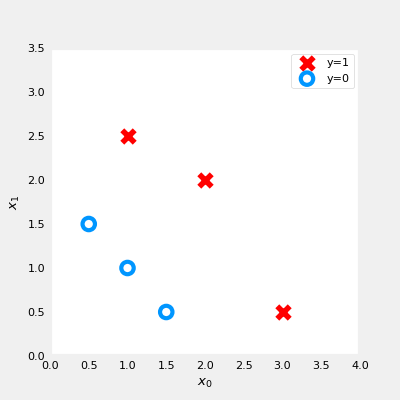

In [3]:
fig,ax = plt.subplots(1,1,figsize=(4,4))
plot_data(X, y, ax)

ax.axis([0, 4, 0, 3.5])
ax.set_ylabel('$x_1$')
ax.set_xlabel('$x_0$')
plt.show()

## Mô hình hồi quy logistic


* Giả sử bạn muốn training mô hình logistic regression trên dữ liệu này có dạng   

  $f(x) = g(w_0x_0+w_1x_1 + b)$
  
  trong đó $g(z) = \frac{1}{1+e^{-z}}$, là hàm sigmoid


* Giả sử bạn đã training mô hình và nhận được các tham số là $b = -3, w_0 = 1, w_1 = 1$. Đó là,

  $f(x) = g(x_0+x_1-3)$

  (Bạn sẽ tìm hiểu cách khớp các tham số này với dữ liệu hơn nữa trong khóa học)
  
  
Chúng ta hãy cố gắng hiểu mô hình được training này đang dự đoán điều gì bằng cách vẽ ranh giới quyết định của nó


### Nhắc lại về logistic regression và ranh giới quyết định

* Hãy nhớ lại rằng đối với logistic regression, mô hình được biểu diễn dưới dạng 

  $$f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = g(\mathbf{w} \cdot \mathbf{x}^{(i)} + b) \tag{1}$$

  trong đó $g(z)$ được gọi là hàm sigmoid và nó ánh xạ tất cả các giá trị đầu vào thành các giá trị từ 0 đến 1:

  $g(z) = \frac{1}{1+e^{-z}}$
  và $\mathbf{w} \cdot \mathbf{x}$ là Tích dot vector:
  
  $$\mathbf{w} \cdot \mathbf{x} = w_0 x_0 + w_1 x_1$$
  
  
 * chúng ta hiểu kết quả đầu ra của mô hình ($f_{\mathbf{w},b}(x)$) là xác suất mà $y=1$ cho $\mathbf{x}$ và được tham số hóa bởi $\mathbf{w}$ và $b$.
* Do đó, để có được dự đoán cuối cùng ($y=0$ hoặc $y=1$) từ mô hình logistic regression, chúng ta có thể sử dụng phương pháp phỏng đoán sau -

  nếu $f_{\mathbf{w},b}(x) >= 0.5$, dự đoán $y=1$
  
  nếu $f_{\mathbf{w},b}(x) < 0.5$, dự đoán $y=0$
  
  
* Hãy vẽ đồ thị hàm sigmoid để xem $g(z) >= 0.5$ ở đây


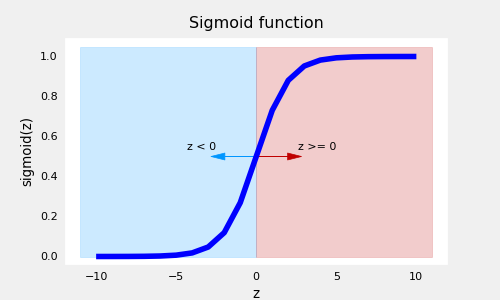

In [ ]:
# Vẽ sigmoid(z) trên một phạm vi giá trị từ -10 đến 10
z = np.arange(-10,11)

fig,ax = plt.subplots(1,1,figsize=(5,3))
# Vẽ đồ thị z và sigmoid(z)
ax.plot(z, sigmoid(z), c="b")

ax.set_title("Sigmoid function")
ax.set_ylabel('sigmoid(z)')
ax.set_xlabel('z')
draw_vthresh(ax,0)

* Như bạn có thể thấy, $g(z) >= 0.5$ cho $z >=0$

* Đối với mẫu logistic regression, $z = \mathbf{w} \cdot \mathbf{x} + b$. Vì vậy,

  nếu $\mathbf{w} \cdot \mathbf{x} + b >= 0$, mô hình dự đoán $y=1$
  
  nếu $\mathbf{w} \cdot \mathbf{x} + b < 0$, mô hình dự đoán $y=0$
  
  
  
### Vẽ ranh giới quyết định

Bây giờ, hãy quay lại ví dụ của chúng ta để hiểu cách mô hình logistic regression đưa ra dự đoán.

* Mô hình logistic regression của chúng ta có dạng

  $f(\mathbf{x}) = g(-3 + x_0+x_1)$


* Từ những gì đã học ở trên, bạn có thể thấy rằng mô hình này dự đoán $y=1$ nếu $-3 + x_0+x_1 >= 0$

Chúng ta hãy xem nó trông như thế nào về mặt đồ họa. Chúng ta sẽ bắt đầu bằng cách vẽ đồ thị $-3 + x_0+x_1 = 0$, tương đương với $x_1 = 3 - x_0$.


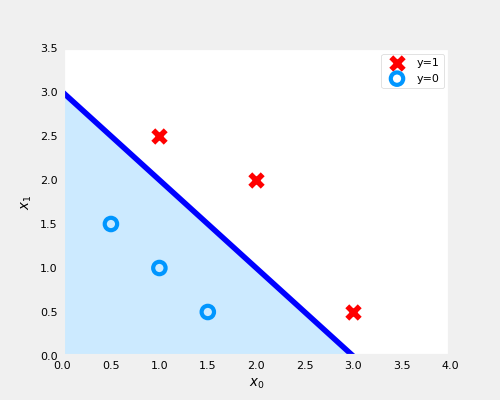

In [ ]:
# Chọn các giá trị trong khoảng từ 0 đến 6
x0 = np.arange(0,6)

x1 = 3 - x0
fig,ax = plt.subplots(1,1,figsize=(5,4))
# Vẽ ranh giới quyết định
ax.plot(x0,x1, c="b")
ax.axis([0, 4, 0, 3.5])

# Điền vào vùng bên dưới dòng
ax.fill_between(x0,x1, alpha=0.2)

# Vẽ dữ liệu gốc
plot_data(X,y,ax)
ax.set_ylabel(r'$x_1$')
ax.set_xlabel(r'$x_0$')
plt.show()

* Trong biểu đồ trên, đường màu xanh biểu thị đường $x_0 + x_1 - 3 = 0$ và nó sẽ giao trục x1 tại 3 (nếu chúng ta đặt $x_1$ = 3, $x_0$ = 0) và trục x0 tại 3 (nếu chúng ta đặt $x_1$ = 0, $x_0$ = 3). 


* Vùng tô bóng biểu thị $-3 + x_0+x_1 < 0$. Vùng phía trên đường thẳng là $-3 + x_0+x_1 > 0$.


* Bất kỳ điểm nào trong vùng bóng mờ (dưới đường kẻ) đều được phân loại là $y=0$.  Bất kỳ điểm nào trên hoặc phía trên đường này đều được phân loại là $y=1$. Đường này được gọi là "ranh giới quyết định".

Như chúng ta đã thấy trong các bài giảng, bằng cách sử dụng các thuật ngữ đa thức bậc cao hơn (ví dụ: $f(x) = g( x_0^2 + x_1 -1)$, chúng ta có thể đưa ra các ranh giới phi tuyến tính phức tạp hơn.


## Chúc mừng!
Bạn đã khám phá ranh giới quyết định trong bối cảnh logistic regression.
